# Hist init — composable workflow

Step-by-step initialization of tweezer grid locations and detection thresholds.

Each step is a separate cell so you can iterate cheaply: re-edit the grid without reloading 2000 images, re-fit thresholds with different `num_bins` instantly, etc.

**Workflow:**
1. Load scan context (metadata only).
2. Compute average image from a small subset.
3. Build mask, auto-detect spots (sanity check).
3.5. **Register CSV → image** (if a `*_coords.csv` exists in the scan dir): pick anchors, fit affine, project all sites. Falls back to the auto-detected spots if no CSV is present.
4. Interactive edit (with detected vs. CSV-inferred coloring).
5. Load images for threshold computation (cached in `images`).
6. Fit per-site double-Gaussian histograms → thresholds.
7. Inspect (grid overlay colored by infidelity, paginated histograms).
8. (optional) Second-pass edit — drop bad sites and re-fit.
9. Save calibration (opt-in to day-folder copy).

## 0. Setup

In [1]:
%matplotlib qt
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')

from yb_analysis.detection import hist_init as hi

## 1. Configure

In [32]:
scan_dir = r"D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_172622"
num_tweezers = 1000

# Mask parameters (Gaussian weighting for masked-intensity readout)
box_size = 9
sigma = 2.0

# Detection parameters
spot_sigma = 2.0    # LoG kernel size — expected spot radius in pixels
min_distance = 10   # minimum spacing between detected peaks

# Editor / registration parameters
snap_window = 8       # px radius around a click to snap to nearest LoG peak
delete_radius = 12    # max distance (px) from a right-click to count as delete
min_anchors = 3       # affine fit needs at least 3 non-collinear correspondences
match_tolerance = 5   # px — projected CSV pos within this of a detected spot counts as 'detected'

# How many images to load
n_avg = 200         # for the average image (fast spot detection)
n_thresh = 2000     # for the threshold histograms

# Histogram fit
num_bins = 50

## 2. Load context + average image

In [33]:
ctx = hi.load_scan_context(scan_dir)
print(f"num_seq={ctx['num_seq']}, num_images_per_seq={ctx['num_images']}, total_frames={ctx['total_frames']}")

avg_image = hi.compute_avg_image(ctx, n_avg=n_avg)
print(f'avg_image shape: {avg_image.shape}')

2026-05-29 18:53:39,472 INFO Averaging 200 of 607 sequence-first images


num_seq=607, num_images_per_seq=2, total_frames=1214
avg_image shape: (1992, 2100)


Plotting single shot image (skip to step 3 for initialization)

In [115]:
# Single-shot image (first sequence-first frame)
from yb_analysis.analysis.load_data import load_images
from matplotlib.patches import Rectangle

shot_idx = ctx['all_first_indices'][12]
single_shot = load_images(ctx['data_path'], [shot_idx])[0].astype(np.float64)

# ---- Display knobs — tweak these for presentation-quality figures ----
# Set vmin/vmax to None to auto-pick percentiles (1, 99.5).
vmin_avg, vmax_avg = 202, 215      # e.g. (200, 215)
vmin_shot, vmax_shot = 205, 218    # e.g. (190, 260)

# White → 399 nm violet colormap (low = white, high = deep violet)
cmap = 'Purples'                     # change to 'gray', 'magma', etc. if preferred

# ---- Crop box for the zoom-in (same coords applied to both images) ----
# (y0, y1, x0, x1) in pixel coordinates — set to None to skip cropping.
crop_box = (1240, 1450, 1280, 1490)    # e.g. (y0, y1, x0, x1)
crop_outline_kwargs = dict(edgecolor='black', facecolor='none',
                           linewidth=0.8, linestyle=':')

# ---- Export knobs ----
save_dir = os.path.join(scan_dir, 'figures')
os.makedirs(save_dir, exist_ok=True)
dpi = 600                            # high-res raster output
save_formats = ('png', 'pdf')        # also write a vector PDF alongside the PNG

def _auto(img, lo, hi):
    if lo is None or hi is None:
        p_lo, p_hi = np.percentile(img, [1, 99.5])
        return (p_lo if lo is None else lo, p_hi if hi is None else hi)
    return lo, hi

def _save_fig(fig, stem):
    """Write a figure to disk in every configured format."""
    for ext in save_formats:
        path = os.path.join(save_dir, f'{stem}.{ext}')
        fig.savefig(path, dpi=dpi, bbox_inches='tight')
        print(f'  wrote {path}')

def _save_single(img, vmin, vmax, title, stem, draw_crop=False):
    """Render one image on its own figure and write it to disk in all save_formats."""
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if draw_crop and crop_box is not None:
        y0, y1, x0, x1 = crop_box
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, **crop_outline_kwargs))
    fig.tight_layout()
    _save_fig(fig, stem)
    return fig, ax

# ---- 1. Combined preview (with crop box drawn) ----
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
va0, va1 = _auto(avg_image, vmin_avg, vmax_avg)
im_a = axes[0].imshow(avg_image, cmap=cmap, vmin=va0, vmax=va1)
axes[0].set_title(f'Average of {min(ctx["num_seq"], n_avg)} images  [{va0:.1f}, {va1:.1f}]')
fig.colorbar(im_a, ax=axes[0], fraction=0.046, pad=0.04)

vs0, vs1 = _auto(single_shot, vmin_shot, vmax_shot)
im_s = axes[1].imshow(single_shot, cmap=cmap, vmin=vs0, vmax=vs1)
axes[1].set_title(f'Single shot (frame {shot_idx})  [{vs0:.1f}, {vs1:.1f}]')
fig.colorbar(im_s, ax=axes[1], fraction=0.046, pad=0.04)

if crop_box is not None:
    y0, y1, x0, x1 = crop_box
    for ax in axes:
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, **crop_outline_kwargs))

print('Saving combined preview (with crop box):')
_save_fig(fig, f'avg_and_single_shot_frame{shot_idx}_with_cropbox')
plt.show()

# ---- 2. Export each full image individually at high resolution ----
print('Saving full-resolution exports:')
_save_single(avg_image, va0, va1,
             f'Average of {min(ctx["num_seq"], n_avg)} images',
             f'avg_image_frame{shot_idx}',
             draw_crop=True)
_save_single(single_shot, vs0, vs1,
             f'Single shot (frame {shot_idx})',
             f'single_shot_frame{shot_idx}',
             draw_crop=True)

# ---- 3. Crop both images with identical coords, save and preview ----
if crop_box is not None:
    y0, y1, x0, x1 = crop_box
    avg_crop = avg_image[y0:y1, x0:x1]
    shot_crop = single_shot[y0:y1, x0:x1]
    print(f'Crop box (y0:y1, x0:x1) = ({y0}:{y1}, {x0}:{x1}) → shape {avg_crop.shape}')

    print('Saving cropped exports:')
    _save_single(avg_crop, va0, va1,
                 f'Average — crop [{y0}:{y1}, {x0}:{x1}]',
                 f'avg_image_crop_y{y0}-{y1}_x{x0}-{x1}')
    _save_single(shot_crop, vs0, vs1,
                 f'Single shot (frame {shot_idx}) — crop [{y0}:{y1}, {x0}:{x1}]',
                 f'single_shot_frame{shot_idx}_crop_y{y0}-{y1}_x{x0}-{x1}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    im_a = axes[0].imshow(avg_crop, cmap=cmap, vmin=va0, vmax=va1)
    axes[0].set_title(f'Average — crop [{y0}:{y1}, {x0}:{x1}]')
    fig.colorbar(im_a, ax=axes[0], fraction=0.046, pad=0.04)
    im_s = axes[1].imshow(shot_crop, cmap=cmap, vmin=vs0, vmax=vs1)
    axes[1].set_title(f'Single shot (frame {shot_idx}) — crop')
    fig.colorbar(im_s, ax=axes[1], fraction=0.046, pad=0.04)
    plt.show()


Saving combined preview (with crop box):
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260527\data_20260527_095604\figures\avg_and_single_shot_frame12_with_cropbox.png
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260527\data_20260527_095604\figures\avg_and_single_shot_frame12_with_cropbox.pdf
Saving full-resolution exports:
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260527\data_20260527_095604\figures\avg_image_frame12.png
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260527\data_20260527_095604\figures\avg_image_frame12.pdf
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260527\data_20260527_095604\figures\single_shot_frame12.png
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260527\data_20260527_095604\figures\single_shot_frame12.pdf
Crop box (y0:y1, x0:x1) = (1240:1450, 1280:1490) → shape (210, 210)
Saving cropped exports:
  wrote D:\OneDrive - Harvard University\Documents - Yb\Dat

Gaussian filter version

In [34]:
# Single-shot image (first sequence-first frame) — smoothed with Gaussian σ=0.8
from yb_analysis.analysis.load_data import load_images
from matplotlib.patches import Rectangle
from scipy.ndimage import gaussian_filter

shot_idx = ctx['all_first_indices'][443]
single_shot_raw = load_images(ctx['data_path'], [shot_idx])[0].astype(np.float64)

# ---- Smoothing ----
smooth_sigma = 0.80
single_shot = gaussian_filter(single_shot_raw, sigma=smooth_sigma)
sm_tag = f'sm{str(smooth_sigma).replace(".", "p")}'   # e.g. 'sm0p8'

# ---- Display knobs — tweak these for presentation-quality figures ----
# Set vmin/vmax to None to auto-pick percentiles (1, 99.5).
vmin_avg, vmax_avg = 202, 215      # e.g. (200, 215)
vmin_shot, vmax_shot = 202, 215    # e.g. (190, 260)

# White → 399 nm violet colormap (low = white, high = deep violet)
cmap = 'magma'                     # change to 'gray', 'magma', etc. if preferred

# ---- Crop box for the zoom-in (same coords applied to both images) ----
# (y0, y1, x0, x1) in pixel coordinates — set to None to skip cropping.
crop_box = (1410, 1580, 510, 680)  #(1150, 1320, 470, 640)    # e.g. (y0, y1, x0, x1)
crop_outline_kwargs = dict(edgecolor='cyan', facecolor='none',
                           linewidth=1.2, linestyle='--')

# ---- Export knobs ----
save_dir = os.path.join(scan_dir, 'figures')
os.makedirs(save_dir, exist_ok=True)
dpi = 600                            # high-res raster output
save_formats = ('png', 'pdf')        # also write a vector PDF alongside the PNG

def _auto(img, lo, hi):
    if lo is None or hi is None:
        p_lo, p_hi = np.percentile(img, [1, 99.5])
        return (p_lo if lo is None else lo, p_hi if hi is None else hi)
    return lo, hi

def _save_fig(fig, stem):
    """Write a figure to disk in every configured format."""
    for ext in save_formats:
        path = os.path.join(save_dir, f'{stem}.{ext}')
        fig.savefig(path, dpi=dpi, bbox_inches='tight')
        print(f'  wrote {path}')

def _save_single(img, vmin, vmax, title, stem, draw_crop=False):
    """Render one image on its own figure and write it to disk in all save_formats."""
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if draw_crop and crop_box is not None:
        y0, y1, x0, x1 = crop_box
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, **crop_outline_kwargs))
    fig.tight_layout()
    _save_fig(fig, stem)
    return fig, ax

# ---- 1. Combined preview (with crop box drawn) ----
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
va0, va1 = _auto(avg_image, vmin_avg, vmax_avg)
im_a = axes[0].imshow(avg_image, cmap=cmap, vmin=va0, vmax=va1)
axes[0].set_title(f'Average of {min(ctx["num_seq"], n_avg)} images  [{va0:.1f}, {va1:.1f}]')
fig.colorbar(im_a, ax=axes[0], fraction=0.046, pad=0.04)

vs0, vs1 = _auto(single_shot, vmin_shot, vmax_shot)
im_s = axes[1].imshow(single_shot, cmap=cmap, vmin=vs0, vmax=vs1)
axes[1].set_title(f'Single shot (frame {shot_idx}, σ={smooth_sigma})  [{vs0:.1f}, {vs1:.1f}]')
fig.colorbar(im_s, ax=axes[1], fraction=0.046, pad=0.04)

if crop_box is not None:
    y0, y1, x0, x1 = crop_box
    for ax in axes:
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, **crop_outline_kwargs))

print('Saving combined preview (with crop box):')
_save_fig(fig, f'avg_and_single_shot_frame{shot_idx}_{sm_tag}_with_cropbox')
plt.show()

# ---- 2. Export each full image individually at high resolution ----
print('Saving full-resolution exports:')
_save_single(avg_image, va0, va1,
             f'Average of {min(ctx["num_seq"], n_avg)} images',
             f'avg_image_frame{shot_idx}',
             draw_crop=True)
_save_single(single_shot, vs0, vs1,
             f'Single shot (frame {shot_idx}, σ={smooth_sigma})',
             f'single_shot_frame{shot_idx}_{sm_tag}',
             draw_crop=True)

# ---- 3. Crop both images with identical coords, save and preview ----
if crop_box is not None:
    y0, y1, x0, x1 = crop_box
    avg_crop = avg_image[y0:y1, x0:x1]
    shot_crop = single_shot[y0:y1, x0:x1]
    print(f'Crop box (y0:y1, x0:x1) = ({y0}:{y1}, {x0}:{x1}) → shape {avg_crop.shape}')

    print('Saving cropped exports:')
    _save_single(avg_crop, va0, va1,
                 f'Average — crop [{y0}:{y1}, {x0}:{x1}]',
                 f'avg_image_crop_y{y0}-{y1}_x{x0}-{x1}')
    _save_single(shot_crop, vs0, vs1,
                 f'Single shot (frame {shot_idx}, σ={smooth_sigma}) — crop [{y0}:{y1}, {x0}:{x1}]',
                 f'single_shot_frame{shot_idx}_{sm_tag}_crop_y{y0}-{y1}_x{x0}-{x1}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    im_a = axes[0].imshow(avg_crop, cmap=cmap, vmin=va0, vmax=va1)
    axes[0].set_title(f'Average — crop [{y0}:{y1}, {x0}:{x1}]')
    fig.colorbar(im_a, ax=axes[0], fraction=0.046, pad=0.04)
    im_s = axes[1].imshow(shot_crop, cmap=cmap, vmin=vs0, vmax=vs1)
    axes[1].set_title(f'Single shot (frame {shot_idx}, σ={smooth_sigma}) — crop')
    fig.colorbar(im_s, ax=axes[1], fraction=0.046, pad=0.04)
    plt.show()


Saving combined preview (with crop box):
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_172622\figures\avg_and_single_shot_frame886_sm0p8_with_cropbox.png
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_172622\figures\avg_and_single_shot_frame886_sm0p8_with_cropbox.pdf
Saving full-resolution exports:
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_172622\figures\avg_image_frame886.png
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_172622\figures\avg_image_frame886.pdf
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_172622\figures\single_shot_frame886_sm0p8.png
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_172622\figures\single_shot_frame886_sm0p8.pdf
Crop box (y0:y1, x0:x1) = (1410:1580, 510:680) → shape (170, 170)
Saving cropped exports:
  wrote D:\OneDrive - Harvard U

In [31]:
# ---- Export full images WITHOUT crop box ----
# Re-derive the display limits (in case this cell is run on its own)
va0, va1 = _auto(avg_image, vmin_avg, vmax_avg)
vs0, vs1 = _auto(single_shot, vmin_shot, vmax_shot)

print('Saving full-resolution exports (no crop box):')

# Average image (no outline)
_save_single(avg_image, va0, va1,
             f'Average of {min(ctx["num_seq"], n_avg)} images',
             f'avg_image_frame{shot_idx}_nocrop',
             draw_crop=False)

# Single shot, Gaussian-smoothed (no outline)
_save_single(single_shot, vs0, vs1,
             f'Single shot (frame {shot_idx}, σ={smooth_sigma})',
             f'single_shot_frame{shot_idx}_{sm_tag}_nocrop',
             draw_crop=False)

plt.show()


Saving full-resolution exports (no crop box):
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260526\data_20260526_091614\figures\avg_image_frame35_nocrop.png
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260526\data_20260526_091614\figures\avg_image_frame35_nocrop.pdf
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260526\data_20260526_091614\figures\single_shot_frame35_sm0p8_nocrop.png
  wrote D:\OneDrive - Harvard University\Documents - Yb\Data\20260526\data_20260526_091614\figures\single_shot_frame35_sm0p8_nocrop.pdf


## 3. Build mask + auto-detect spots

This is a sanity check — it shows what the LoG detector finds without any geometric prior. The output `spots` is also used as a fallback in the next cell when no CSV is present.

In [6]:
mask_mat = hi.make_mask(box_size=box_size, sigma=sigma)

spots = hi.detect_grid(avg_image, num_tweezers,
                       spot_sigma=spot_sigma,
                       min_distance=min_distance,
                       sort=False)
print(f'Auto-detected {len(spots)} / {num_tweezers} spots')

hi.plot_grid_overlay(avg_image, spots)
plt.show()

Auto-detected 1000 / 1000 spots


In [113]:
spots, rot = hi.sort_grid_rotated(spots, return_rotation=True)
print(f'Auto-detected {len(spots)} / {num_tweezers} spots (lattice rotation {rot:+.2f}°)')


TypeError: sort_grid_rotated() got an unexpected keyword argument 'return_rotation'

## 3.5. Register CSV → image (or fall back to auto-detect)

If a `*_coords.csv` file exists in `scan_dir`, this opens a side-by-side picker:
- **Left**: averaged atom image with **cyan rings** showing every auto-detected spot from cell 3 — click any of them.
- **Right**: scatter of CSV positions in µm with index labels — click the matching index.

Image clicks **snap to the nearest detected spot** within `match_tolerance` px (more precise than free-clicking). Repeat ≥ `min_anchors` times, press **Done**.

The affine transform is fit, all CSV points are projected into image pixels. Each CSV site is then matched to the nearest detected spot:
- **lime** = CSV site matched to a detected atom-image spot
- **orange** = CSV site with no matching atom-image spot (geometrically inferred only)
- **cyan** = "ghost" trap — a detected atom-image spot that's NOT in the CSV (loaded with atoms but unintended). Set `include_ghosts=False` to discard them at this stage; otherwise they're kept and you can right-click to delete in the editor.

If no CSV is found, the cell prints a notice and uses the auto-detected `spots` from the previous cell as the initial grid.

In [7]:
reg = hi.register_csv_grid(avg_image, scan_dir,
                           detected_spots=spots,
                           include_ghosts=True,
                           spot_sigma=spot_sigma,
                           snap_window=snap_window,
                           match_tolerance=match_tolerance,
                           min_anchors=min_anchors)

if reg is None:
    print('No coords CSV found — falling back to auto-detect grid.')
    initial_grid = spots
    is_detected = None
    is_csv = None
else:
    csv_mask = reg['is_csv']
    n_csv_det = int((csv_mask & reg['is_detected']).sum())
    n_csv_inf = int((csv_mask & ~reg['is_detected']).sum())
    n_ghosts = int((~csv_mask).sum())
    print(f"CSV: {os.path.basename(reg['csv_path'])} | "
          f"csv-detected {n_csv_det} | csv-inferred {n_csv_inf} | "
          f"ghosts {n_ghosts} | total grid {len(reg['grid'])} | "
          f"max anchor residual {reg['residuals_px'].max():.2f} px")
    initial_grid = reg['grid']
    is_detected = reg['is_detected']
    is_csv = reg['is_csv']
    hi.plot_grid_overlay(avg_image, initial_grid, box_size=box_size)
    plt.show()

2026-05-29 17:41:35,120 INFO Loaded 3270 tweezers from tri_62x61_5um_3270tweezers_coords.csv
2026-05-29 17:42:07,261 INFO Registration: 3 anchors, residual max/mean=0.00/0.00 px, csv-detected=1000, csv-inferred=2270, ghosts=0 (match_tolerance=5.0 px)


CSV: tri_62x61_5um_3270tweezers_coords.csv | csv-detected 1000 | csv-inferred 2270 | ghosts 0 | total grid 3270 | max anchor residual 0.00 px


## 4. Interactive edit

**Mouse**: left-click adds a new site. **Right-click toggles** the nearest site between alive/dead — a "deleted" site is kept as a tombstone (dim gray, dashed) so its CSV index is preserved through to the histograms.  
**Keyboard** (cursor over image): `d` mark nearest alive site dead · `u` undo · `Enter` finish.  
**Buttons**: Done · Reset · Snap toggle · Contrast slider.

Site colors:
- **lime** = CSV site, matched to a real atom-image spot
- **orange** = CSV site, no matching spot (geometrically inferred)
- **cyan** = ghost trap (detected, not in CSV) — keep or right-click to mark dead
- **dim gray, dashed** = deleted (tombstoned) — its CSV index slot still appears in step 8 as "DELETED"
- **red** = newly added by left-click

Labels show CSV index for CSV sites and `+row` for non-CSV (ghosts/added).

In [8]:
edit_result = hi.edit_grid(avg_image, initial_grid,
                           spot_sigma=spot_sigma,
                           snap=True,
                           snap_window=snap_window,
                           delete_radius=delete_radius,
                           is_detected=is_detected,
                           is_csv=is_csv,
                           csv_indices=(reg['csv_indices'] if reg is not None else None),
                           box_size=box_size,
                           sort=False)   # preserve CSV order; tombstone dead

grid         = edit_result['grid']
csv_indices  = edit_result['csv_indices']
is_alive     = edit_result['is_alive']
is_csv_post  = edit_result['is_csv']
is_detected_post = edit_result['is_detected']

print(f"After edit: {len(grid)} rows ({int(is_alive.sum())} alive, "
      f"{int((~is_alive).sum())} deleted, "
      f"{int(is_csv_post.sum())} CSV, {int((~is_csv_post).sum())} non-CSV)")

After edit: 3270 rows (3270 alive, 0 deleted, 3270 CSV, 0 non-CSV)


## 5. Load images for threshold computation

This is the slow step. The `images` array is reused by every subsequent re-fit, so you only pay it once.

In [9]:
images = hi.load_threshold_images(ctx, n_thresh=n_thresh)
print(f'images shape: {images.shape}')

2026-05-29 17:42:23,492 INFO Loading 108 images for threshold computation


images shape: (108, 1992, 2100)


## 6. Fit per-site thresholds

Re-run this cell after tweaking `num_bins`, the mask, or the grid — the slow image load above is cached.

In [10]:
hist_data, thresholds, gauss_fits, infidelities = hi.compute_thresholds(
    images, grid, mask_mat, num_bins=num_bins, is_alive=is_alive
)
print(f'Mean infidelity:   {np.nanmean(infidelities):.4e}')
print(f'Median infidelity: {np.nanmedian(infidelities):.4e}')

n_show = min(10, int(np.isfinite(infidelities).sum()))
finite_idx = np.where(np.isfinite(infidelities))[0]
worst = finite_idx[np.argsort(infidelities[finite_idx])[-n_show:][::-1]]
print(f'Worst {n_show} sites:')
for rank, i in enumerate(worst, 1):
    label = (f'CSV index {csv_indices[i]}' if csv_indices[i] > 0
             else f'row {i + 1} (non-CSV)')
    print(f'  {rank:>2}. {label:<22}  infidelity = {infidelities[i]:.4e}')

Mean infidelity:   4.6236e-02
Median infidelity: 3.3572e-02
Worst 10 sites:
   1. CSV index 2060          infidelity = 6.7557e-01
   2. CSV index 2520          infidelity = 6.6237e-01
   3. CSV index 1734          infidelity = 5.2613e-01
   4. CSV index 1303          infidelity = 5.0448e-01
   5. CSV index 2918          infidelity = 4.8879e-01
   6. CSV index 530           infidelity = 4.6194e-01
   7. CSV index 2485          infidelity = 4.6118e-01
   8. CSV index 2764          infidelity = 4.5990e-01
   9. CSV index 2779          infidelity = 4.4398e-01
  10. CSV index 1779          infidelity = 4.2838e-01


## 7. Inspect — grid overlay colored by infidelity

In [11]:
hi.plot_grid_overlay(avg_image, grid[is_alive],
                     infidelities=infidelities[is_alive],
                     labels=csv_indices[is_alive],   # preserve CSV identity
                     box_size=box_size)
plt.show()

## 8. Inspect — paginated per-site histograms

Single figure with **Prev / Next** buttons (or **Left / Right arrow** keys, **Home / End** to jump). Pass `sort_by='infidelity'` to view sites worst-first — useful when you have thousands of tweezers.

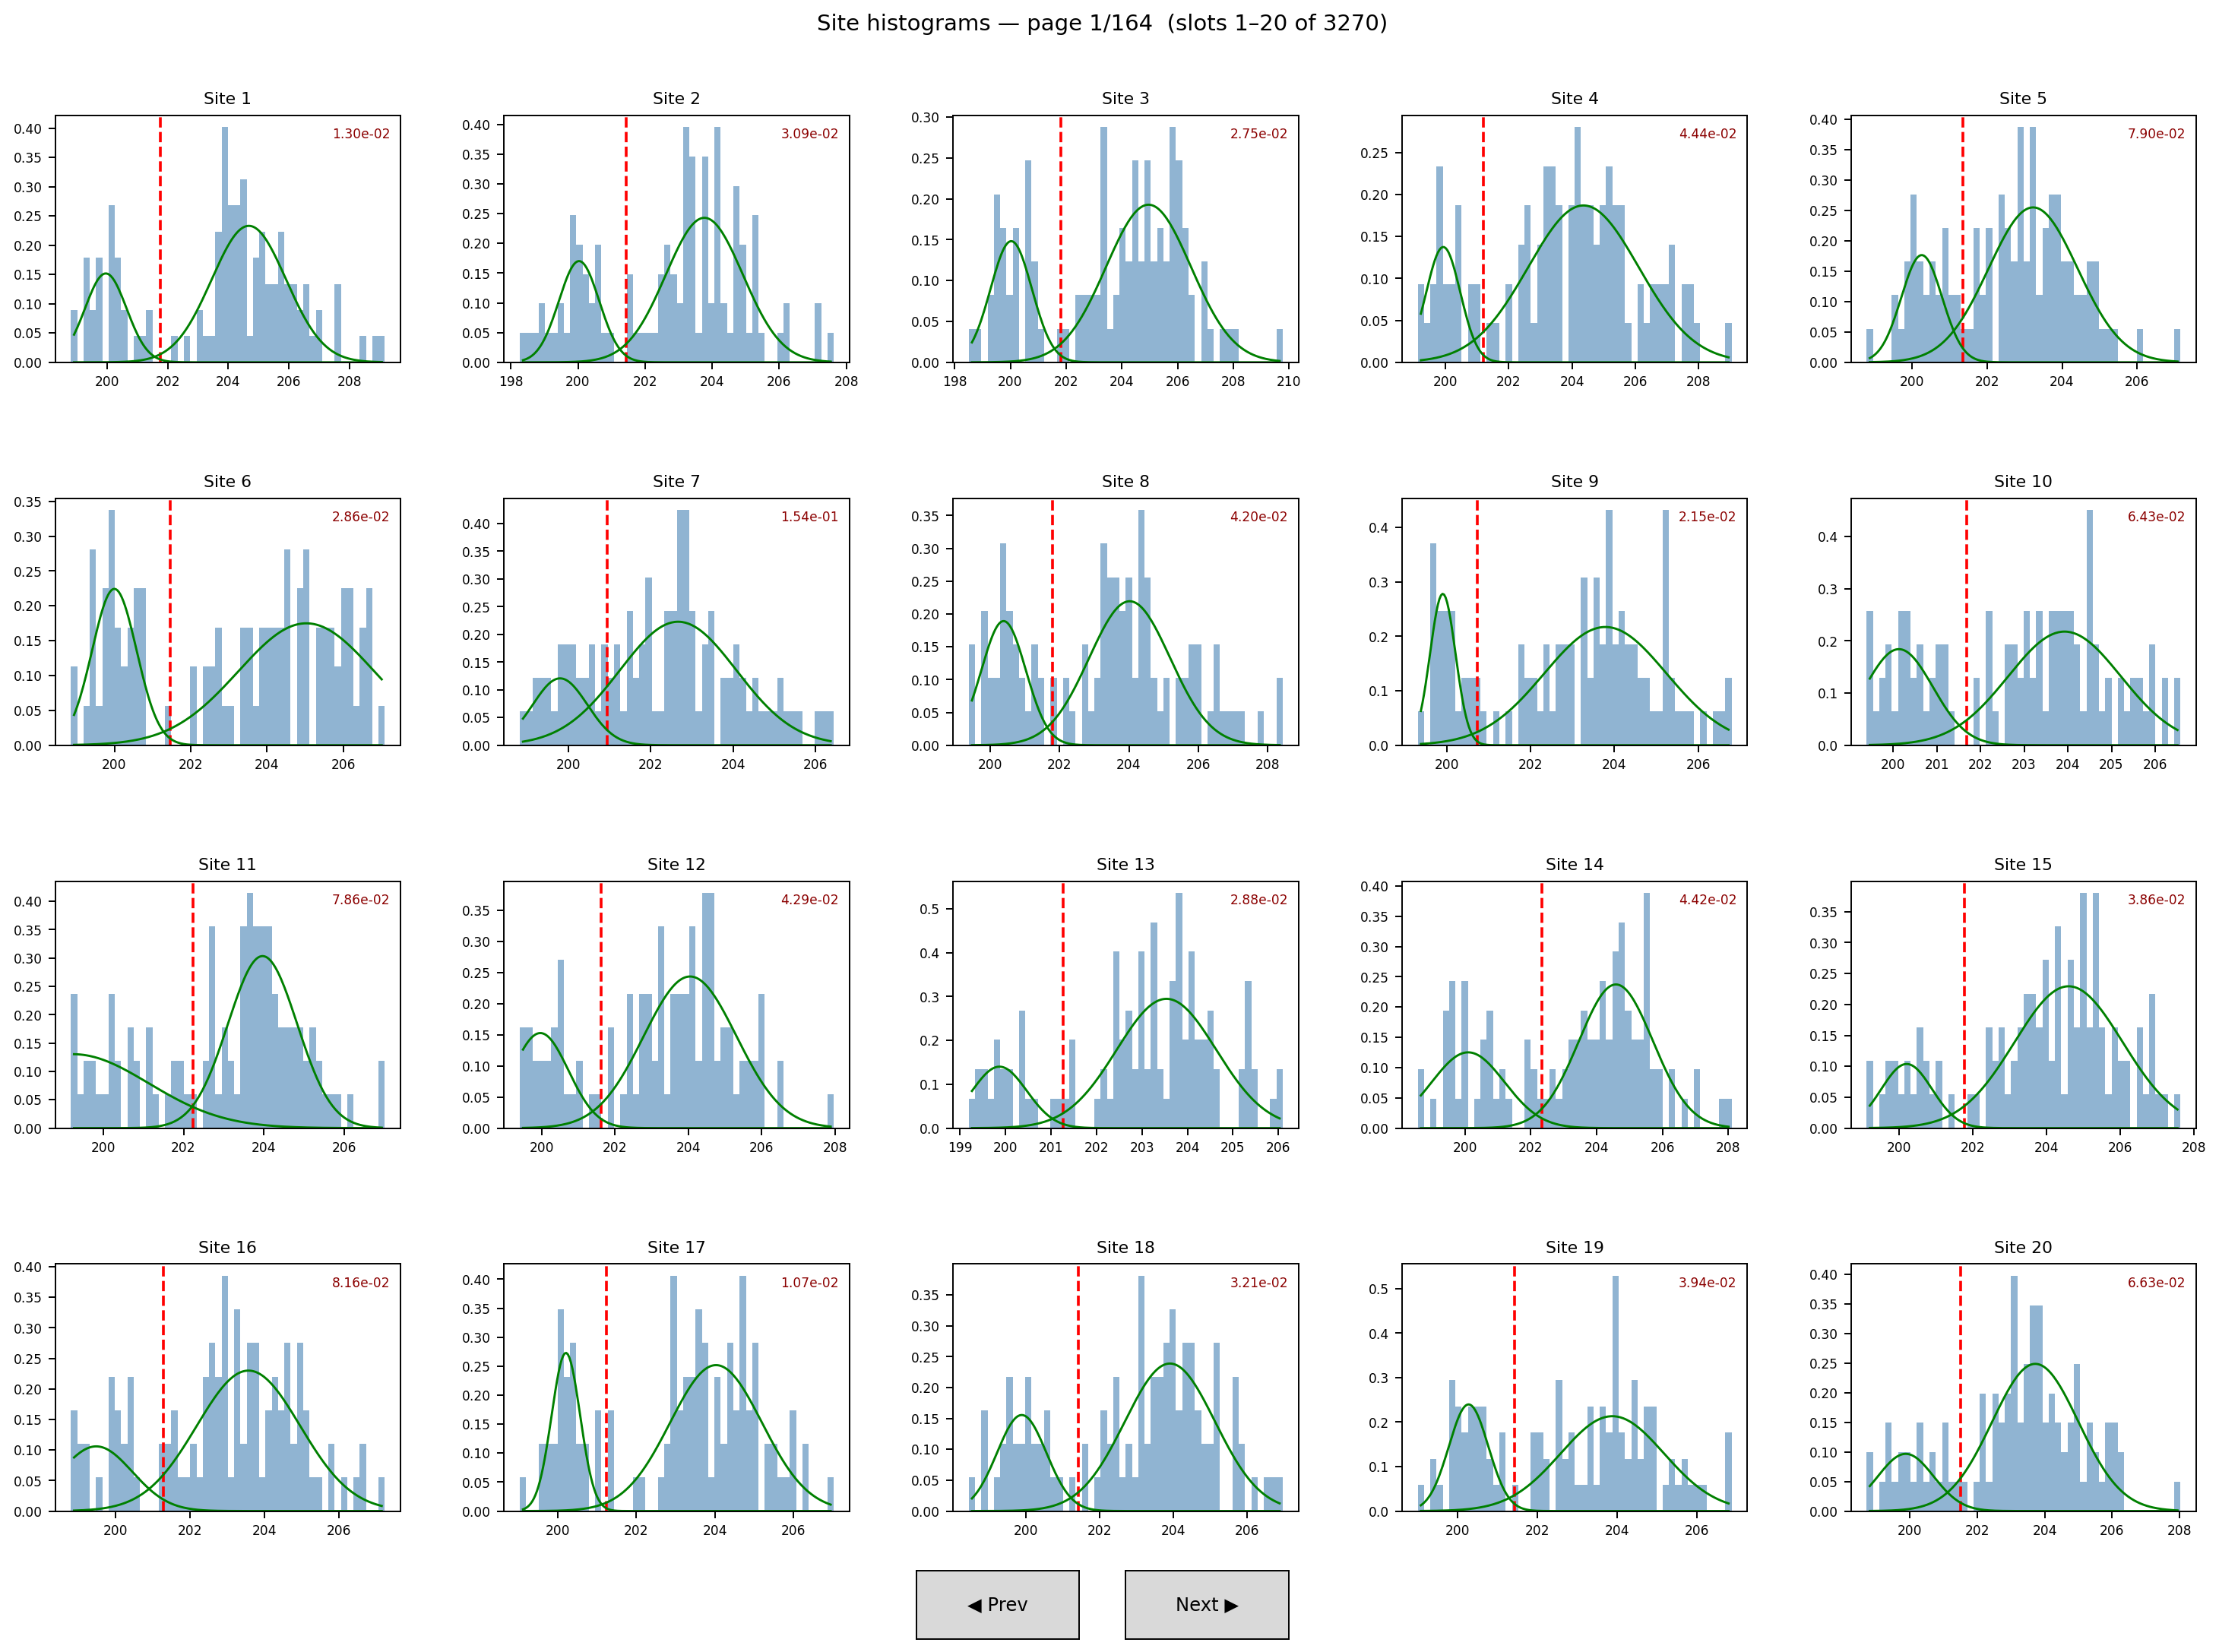

In [23]:
hi.plot_histograms(hist_data, thresholds, gauss_fits, infidelities,
                   csv_indices=csv_indices,
                   is_alive=is_alive,
                   sort_by=None)   # set 'infidelity' to scan worst sites first

## 9. (optional) Second-pass edit — drop bad sites in-place

Opens the editor with sites colored by their infidelity (green = good, red = bad). Right-click red sites to drop them, then re-run cell 6 to refit thresholds on the trimmed grid.

Skip this cell if you're happy with the first pass.

In [123]:
edit_result = hi.edit_grid(avg_image, grid,
                           spot_sigma=spot_sigma,
                           snap=True,
                           snap_window=snap_window,
                           delete_radius=delete_radius,
                           infidelities=infidelities,
                           csv_indices=csv_indices,
                           is_alive=is_alive,
                           box_size=box_size,
                           sort=False)
grid        = edit_result['grid']
csv_indices = edit_result['csv_indices']
is_alive    = edit_result['is_alive']
print(f'After second-pass edit: {int(is_alive.sum())} alive / {int((~is_alive).sum())} deleted — re-run cell 6 to refit.')

After second-pass edit: 456 alive / 25 deleted — re-run cell 6 to refit.


## 10. Save calibration

Writes `gridLocations.txt`, `threshold.mat`, `histData.mat` into `scan_dir`. Tombstoned (deleted) sites are dropped before writing.

`gridLocations.txt` is written with **three columns** when `csv_indices` is supplied: `Y\tX\tSite_Index`. The Site_Index column carries the CSV index for CSV-derived rows and `-1` for ghosts / user-clicked rows. Deleted CSV indices simply don't appear in the file — the gap in the Site_Index sequence makes the omission obvious.

Set `save_to_day_folder=True` only when this scan is the *day's* reference calibration — it overwrites the day-level files.

In [13]:
hi.save_calibration(scan_dir, grid, thresholds, infidelities,
                    gauss_fits, hist_data,
                    is_alive=is_alive,         # drop tombstones from saved files
                    csv_indices=csv_indices,   # write Site_Index column (CSV idx; -1 for non-CSV)
                    save_to_day_folder=False)

2026-05-29 17:43:48,625 INFO Saved D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_165807\gridLocations.txt
2026-05-29 17:43:48,670 INFO Saved D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_165807\threshold.mat
2026-05-29 17:43:48,763 INFO Saved D:\OneDrive - Harvard University\Documents - Yb\Data\20260529\data_20260529_165807\histData.mat


## (Optional) Bundle results

In [ ]:
result = {
    'grid_locations': grid,
    'thresholds': thresholds,
    'infidelities': infidelities,
    'gauss_fits': gauss_fits,
    'hist_data': hist_data,
    'mask_mat': mask_mat,
    'avg_image': avg_image,
    'scan_dir': scan_dir,
    'ctx': ctx,
    'registration': reg,
}
print({k: (v.shape if hasattr(v, 'shape') else type(v).__name__) for k, v in result.items()})